# 02 - Train the forecast model

Trains the model used by the *Forecast* tab. It uses **exactly the same code as the Retrain button in the app**
(`data_tools.train_candidate`), so the notebook and the app can never disagree.

How the model works: it looks at *this month's price, the prices of the 3 months before, the month number and the
district/commodity*, and predicts **next month's price**. To forecast further ahead it feeds its own predictions back in.

In [1]:
import os
os.chdir("..")                      # data_tools uses paths relative to the project folder
import pandas as pd
import data_tools as dt

print("working folder:", os.path.basename(os.getcwd()))

working folder: Project_Final


## 1. The data the app uses (generated monthly data, plus real uploaded data if there is any)

In [2]:
monthly = dt.load_effective_monthly()
print(monthly["source"].value_counts().to_string())
monthly.head()

source
generated    17766


,date,location,commodity,price_per_kg,source
0,2025-01-01,Bagerhat,Broiler chicken,173.233524,generated
1,2025-02-01,Bagerhat,Broiler chicken,170.519381,generated
2,2025-03-01,Bagerhat,Broiler chicken,175.081401,generated
3,2025-04-01,Bagerhat,Broiler chicken,180.101153,generated
4,2025-05-01,Bagerhat,Broiler chicken,171.640536,generated


## 2. Train and test

The newest 3 months are held back. The model learns from the older months and is then tested on those 3 months.
The result is compared with the simplest possible forecast, *"next month = this month"* (the **baseline**).
The saved model is finally trained again on **all** months.

In [3]:
candidate = dt.train_candidate(monthly)
m = candidate["metrics"]

pd.DataFrame({
    "Result": ["Rows used", "Series (district x commodity)", "Test months", "Test rows",
               "Model MAE (Tk/kg)", "Baseline MAE (Tk/kg)", "Model MAPE (%)"],
    "Value": [str(m["rows"]), str(m["series"]), str(m["test_months"]), str(m["test_rows"]),
              f'{m["mae_model"]:.2f}', f'{m["mae_baseline"]:.2f}', f'{m["mape_model"]:.2f}'],
})

,Result,Value
0,Rows used,14382
1,Series (district x commodity),846
2,Test months,3
3,Test rows,2538
4,Model MAE (Tk/kg),7.04
5,Baseline MAE (Tk/kg),8.03
6,Model MAPE (%),2.83


> **How to read this:** MAE is the average mistake in Tk/kg on months the model has not seen (lower is better).
> On the *generated* data, any model that smooths the noise beats the baseline by a fixed amount, so a good score here
> proves little. The comparison only becomes meaningful when real monthly prices are uploaded.

## 3. Save the model

In [4]:
dt.save_model(candidate["model"], candidate["features"])
print("saved:", dt.MODEL_PATH, "and", dt.FEATURES_PATH, "-", len(candidate["features"]), "input columns")

saved: models/model1_forecast.json and models/model1_features.json - 128 input columns


## 4. Try a forecast

In [5]:
model, features = dt.load_model()

result = dt.forecast_series(monthly, model, features, "Dhaka", "Broiler chicken", months_ahead=6)
print("last known month:", result["last_known"].strftime("%Y-%m"), "| data basis:", result["source"])
result["forecast"].assign(price=result["forecast"]["price"].round(2))

last known month: 2026-09 | data basis: generated


,date,price
0,2026-10-01,176.46
1,2026-11-01,175.50
2,2026-12-01,174.63
3,2027-01-01,176.57
4,2027-02-01,178.82
5,2027-03-01,178.82


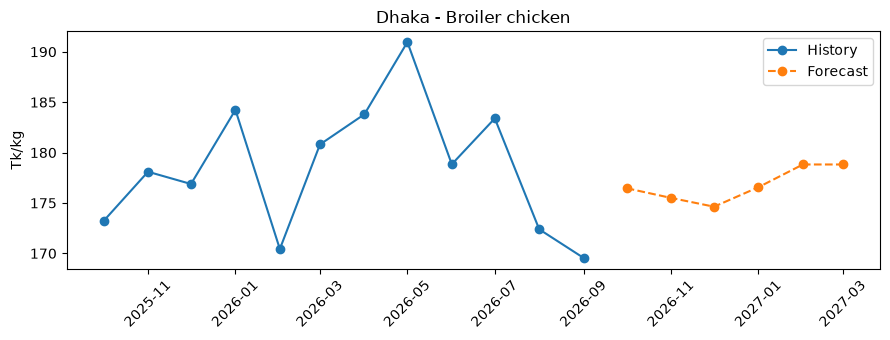

In [6]:
import matplotlib.pyplot as plt

h, f = result["history"], result["forecast"]
plt.figure(figsize=(9, 3.5))
plt.plot(h["date"], h["price_per_kg"], marker="o", label="History")
plt.plot(f["date"], f["price"], marker="o", linestyle="--", label="Forecast")
plt.title("Dhaka - Broiler chicken"); plt.ylabel("Tk/kg"); plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.show()